# Self-consistency on a finite ribbon: edge magnetism
A honeycomb zigzag ribbon is finite in one direction and periodic in the other, and it hosts a hallmark feature: a pair of nearly flat, degenerate bands near $E=0$ localized on its two zigzag edges. That huge density of states at the Fermi level makes the edges unstable to arbitrarily weak Hubbard repulsion, driving spontaneous antiferromagnetic order between the two edges — the ribbon analogue of the bulk instability from the self-consistency notebook, but now spatially resolved.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### Create a 10-cell-wide zigzag ribbon
$$ H = \sum_{\langle ij \rangle} c^\dagger_i c_j $$

In [2]:
g = geometry.honeycomb_zigzag_ribbon(10) # create the geometry
h = g.get_hamiltonian() # create hamiltonian of the system

### Self-consistent Hubbard mean field
$$ H_U = U\sum_i c^\dagger_{i,\uparrow} c_{i,\uparrow} c^\dagger_{i,\downarrow} c_{i,\downarrow} \approx 
U\sum_i \langle c^\dagger_{i,\uparrow} c_{i,\uparrow} \rangle c^\dagger_{i,\downarrow} c_{i,\downarrow} +
U\sum_i c^\dagger_{i,\uparrow} c_{i,\uparrow} \langle c^\dagger_{i,\downarrow} c_{i,\downarrow} \rangle $$

In [3]:
hscf = h.get_mean_field_hamiltonian(U=1.0,filling=0.5,mf="antiferro") # perform SCF calculation

### Where does the magnetization live?
`extract("mz")` returns the converged magnetization on every site. Plotting it against the transverse coordinate $y$ shows it is largest at the two zigzag edges and decays into the ribbon interior — real-space confirmation of the edge-localized instability.

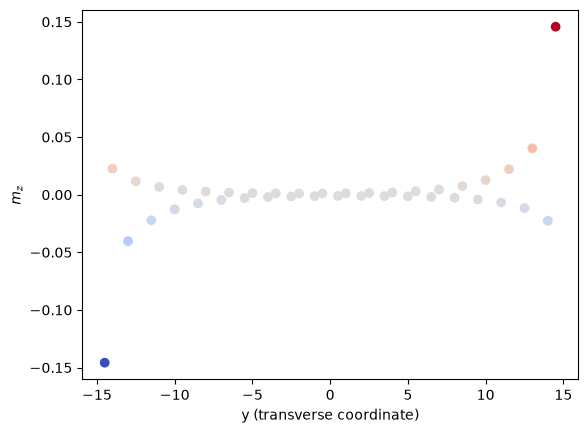

In [4]:
mz = hscf.extract("mz") # magnetization on each site
plt.scatter(g.y,mz,c=mz,cmap="coolwarm")
plt.xlabel("y (transverse coordinate)") ; plt.ylabel("$m_z$")
plt.show()

### Diagonalize the non-interacting and interacting Bloch Hamiltonian
The following function will obtain the Bloch eigenvalues $\epsilon_k$ defined as
$$ H \left | \Psi_k \right \rangle = \epsilon_k \left | \Psi_k \right \rangle $$

In [5]:
(k,e) = h.get_bands() # get the bandstructure
(kscf,escf) = hscf.get_bands() # get the bandstructure

### Plot the band structure: the flat edge bands split open
Non-interacting, the two edge bands are pinned near $E=0$ over the whole flat portion of the Brillouin zone. Once the self-consistent magnetization sets in, the edges become effectively spin-polarized and the bands split, opening a small gap.

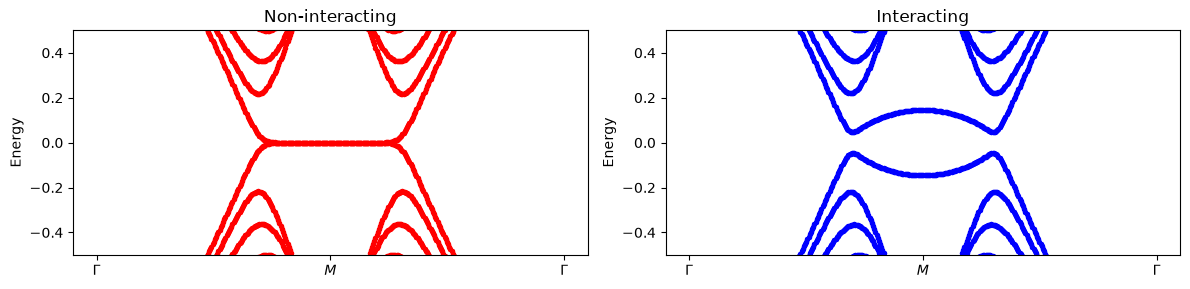

In [6]:
fig = plt.figure(figsize=(12, 3)) # set the right ratio
plt.subplot(121)
plt.title("Non-interacting")
plt.scatter(k/max(k),e,c="red",s=8) # do a scatter plot
plt.ylabel("Energy") # set the y label
plt.xticks([0.,0.5,1.],["$\Gamma$","$M$","$\Gamma$"])
plt.ylim([-0.5,0.5])

plt.subplot(122)
plt.title("Interacting")
plt.scatter(kscf/max(kscf),escf,c="blue",s=8) # do a scatter plot
plt.ylabel("Energy") # set the y label
plt.xticks([0.,0.5,1.],["$\Gamma$","$M$","$\Gamma$"])
plt.ylim([-0.5,0.5])

plt.tight_layout()
plt.show()